In [9]:
import pandas as pd
import graphviz

# 一、 用戶與核心屬性模組 (User Profile)
users_df = pd.DataFrame(columns=[
    'user_id', 'role', 'name', 'email', 'department', 'enrollment_year', 'graduation_year'
])

# 二、 DNA 數據庫模組 (Academic & Activity DNA)
academic_records_df = pd.DataFrame(columns=[
    'record_id', 'user_id', 'course_name', 'grade', 'semester'
])

activity_records_df = pd.DataFrame(columns=[
    'activity_id', 'user_id', 'activity_type', 'activity_name', 'role_or_award'
])

# 三、 職涯軌跡模組 (Career Mirror Path)
career_milestones_df = pd.DataFrame(columns=[
    'milestone_id', 'user_id', 'milestone_type', 'title_or_role', 'organization', 'achieved_date'
])

# 四、 媒合與互動模組 (Match & Coffee Chat)
coffee_chats_df = pd.DataFrame(columns=[
    'chat_id', 'student_id', 'alumni_id', 'status'
])

# 五、 專案與知識庫模組 (Micro-tasks & Knowledge Base)
micro_tasks_df = pd.DataFrame(columns=[
    'task_id', 'poster_id', 'title', 'description', 'required_background', 'status'
])

interview_experiences_df = pd.DataFrame(columns=[
    'experience_id', 'author_id', 'company_name', 'content'
])

qa_threads_df = pd.DataFrame(columns=[
    'thread_id', 'asker_id', 'question_content', 'responder_id', 'answer_content'
])

In [10]:
schema_description = {
    "users_df (使用者主表)": {
        "user_id": "唯一識別碼 (PK)",
        "role": "角色 (student 在校生 / alumni 校友)",
        "name": "使用者姓名",
        "email": "聯絡信箱",
        "department": "就讀或畢業科系",
        "enrollment_year": "入學年份",
        "graduation_year": "畢業或預計畢業年份"
    },
    "academic_records_df (學術DNA表)": {
        "record_id": "唯一識別碼 (PK)",
        "user_id": "關聯使用者 (FK)",
        "course_name": "課程名稱 (用以分析修課偏好)",
        "grade": "成績表現",
        "semester": "修課學期 (如：112-1)"
    },
    "activity_records_df (活動DNA表)": {
        "activity_id": "唯一識別碼 (PK)",
        "user_id": "關聯使用者 (FK)",
        "activity_type": "活動類型 (社團 / 競賽 / 實習)",
        "activity_name": "活動或社團名稱",
        "role_or_award": "擔任幹部職位或競賽名次",
    },
    "career_milestones_df (職涯軌跡表)": {
        "milestone_id": "唯一識別碼 (PK)",
        "user_id": "關聯校友 (FK)",
        "milestone_type": "節點類型 (實習 / 正職 / 證照)",
        "title_or_role": "職稱或證照名稱",
        "organization": "公司或發證機構名稱",
        "achieved_date": "完成時間"
    },
    "coffee_chats_df (Coffee Chat 表)": {
        "chat_id": "唯一識別碼 (PK)",
        "student_id": "發起交流的學生 (FK)",
        "alumni_id": "接受交流的校友 (FK)",
        "status": "邀請狀態 (待確認 / 已接受 / 婉拒)"
    },
    "micro_tasks_df (微任務專案表)": {
        "task_id": "唯一識別碼 (PK)",
        "poster_id": "發布任務的校友 (FK)",
        "title": "任務標題",
        "description": "任務詳細內容 (如協助數據整理)",
        "required_background": "特定背景要求",
        "status": "任務狀態 (開放中 / 已結束)"
    },
    "interview_experiences_df (知識庫表)": {
        "experience_id": "唯一識別碼 (PK)",
        "author_id": "分享經驗的校友 (FK)",
        "company_name": "面試或實習的公司名稱",
        "content": "經驗與建議內容",
    },
    "qa_threads_df (相似背景問答表)": {
        "thread_id": "唯一識別碼 (PK)",
        "asker_id": "提問學生 (FK)",
        "question_content": "問題內容",
        "responder_id": "回覆的校友 (FK)",
        "answer_content": "精準答覆內容"
    }
}

print("=== 校園職涯媒合平台：資料庫欄位描述 ===\n")
for table_name, columns in schema_description.items():
    print(f"📌 {table_name}")
    for col, desc in columns.items():
        print(f"  ├── {col}: {desc}")
    print("-" * 40)

=== 校園職涯媒合平台：資料庫欄位描述 ===

📌 users_df (使用者主表)
  ├── user_id: 唯一識別碼 (PK)
  ├── role: 角色 (student 在校生 / alumni 校友)
  ├── name: 使用者姓名
  ├── email: 聯絡信箱
  ├── department: 就讀或畢業科系
  ├── enrollment_year: 入學年份
  ├── graduation_year: 畢業或預計畢業年份
----------------------------------------
📌 academic_records_df (學術DNA表)
  ├── record_id: 唯一識別碼 (PK)
  ├── user_id: 關聯使用者 (FK)
  ├── course_name: 課程名稱 (用以分析修課偏好)
  ├── grade: 成績表現
  ├── semester: 修課學期 (如：112-1)
----------------------------------------
📌 activity_records_df (活動DNA表)
  ├── activity_id: 唯一識別碼 (PK)
  ├── user_id: 關聯使用者 (FK)
  ├── activity_type: 活動類型 (社團 / 競賽 / 實習)
  ├── activity_name: 活動或社團名稱
  ├── role_or_award: 擔任幹部職位或競賽名次
----------------------------------------
📌 career_milestones_df (職涯軌跡表)
  ├── milestone_id: 唯一識別碼 (PK)
  ├── user_id: 關聯校友 (FK)
  ├── milestone_type: 節點類型 (實習 / 正職 / 證照)
  ├── title_or_role: 職稱或證照名稱
  ├── organization: 公司或發證機構名稱
  ├── achieved_date: 完成時間
----------------------------------------
📌 coffee_chats_df (Coffee Ch

In [11]:
# 1. 初始化 Graphviz 畫布
dot = graphviz.Digraph('Pandas_ERD_HTML', node_attr={'fontname': 'Helvetica'})
dot.attr(rankdir='TB') 

# 2. 定義轉換函數：使用 HTML-like Label 繪製表格
def add_table_node(dot_obj, table_name, df, pk_column):
    cols_html = ""
    
    # 建立橫向欄位
    for col in df.columns:
        if col == pk_column:
            # 主鍵加上 <u> 畫底線，並指定 PORT 讓關聯線可以連到這個特定的格子
            cols_html += f'<TD PORT="{col}"><u>{col}</u></TD>'
        else:
            cols_html += f'<TD PORT="{col}">{col}</TD>'
            
    # 組裝 HTML 結構
    # 第一列 (TR) 是資料表名稱：去邊框 (BORDER="0") 且靠左對齊 (ALIGN="LEFT")
    # 第二列 (TR) 是所有欄位，橫向展開
    label_html = f'''<
    <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="4">
        <TR>
            <TD BORDER="0" ALIGN="LEFT"><B>{table_name}</B></TD>
        </TR>
        <TR>
            {cols_html}
        </TR>
    </TABLE>
    >'''
    
    # 新增節點，形狀設定為 plaintext 才能正確渲染 HTML 表格
    dot_obj.node(table_name.lower(), label_html, shape='plaintext')

# 3. 新增所有節點
add_table_node(dot, 'Users', users_df, 'user_id')
add_table_node(dot, 'Academic_Records', academic_records_df, 'record_id')
add_table_node(dot, 'Activity_Records', activity_records_df, 'activity_id')
add_table_node(dot, 'Career_Milestones', career_milestones_df, 'milestone_id')
add_table_node(dot, 'Coffee_Chats', coffee_chats_df, 'chat_id')
add_table_node(dot, 'Micro_Tasks', micro_tasks_df, 'task_id')
add_table_node(dot, 'Interview_Experiences', interview_experiences_df, 'experience_id')
add_table_node(dot, 'QA_Threads', qa_threads_df, 'thread_id')

# 4. 指定關聯線
# 外圍資料表關聯至 Users 表
dot.edge('academic_records:user_id', 'users:user_id', color='blue')
dot.edge('activity_records:user_id', 'users:user_id', color='blue')
dot.edge('career_milestones:user_id', 'users:user_id', color='blue')

# 互動與專案表的關聯 (發起與接收)
dot.edge('coffee_chats:student_id', 'users:user_id', color='green')
dot.edge('coffee_chats:alumni_id', 'users:user_id', color='purple')

dot.edge('micro_tasks:poster_id', 'users:user_id', color='orange')
dot.edge('interview_experiences:author_id', 'users:user_id', color='orange')

dot.edge('qa_threads:asker_id', 'users:user_id', color='green')
dot.edge('qa_threads:responder_id', 'users:user_id', color='purple')

# 5. 輸出並檢視圖片
dot.render('campus_match_erd_html', format='png', view=True)

'campus_match_erd_html.png'

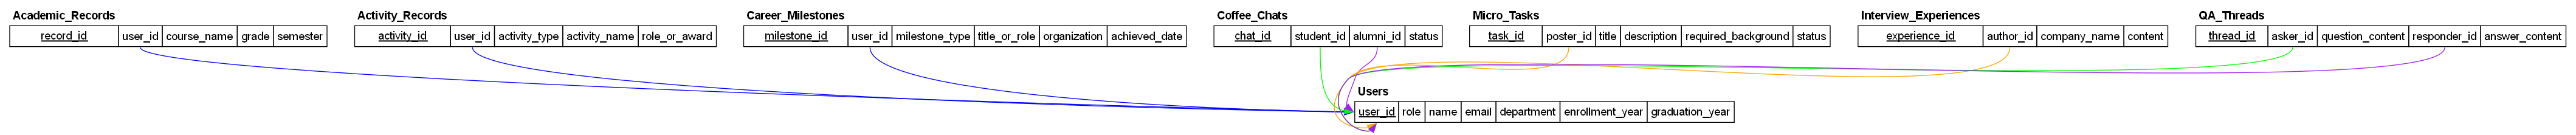

In [12]:
from IPython.display import Image, display

display(Image(filename='campus_match_erd_html.png', width=800))